In [47]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
 
data = Table.read("galaxy-line-fluxes.fits")
print(data)

OII_3727_FLUX NEIII_3869_FLUX H_BETA_4861_FLUX ... SII_6716_FLUX label
------------- --------------- ---------------- ... ------------- -----
    25.540579         11.2066         8.351458 ...      14.86451     C
    353.38052       5.3133583        138.88454 ...      391.7372     C
     65.03466       5.4985023         41.57892 ...      64.81144     S
     72.18892       1.5433259        41.293507 ...     57.860207     S
    219.77934       6.7553387       100.012474 ...     145.49347     S
   107.577896       2.3182347        11.910394 ...     128.65822     A
    151.71338       3.8999686        122.88224 ...     202.26248     S
    40.566685       2.9712958        34.495895 ...       29.5171     C
     86.70685       14.813063        32.878166 ...     108.01842     A
    1704.9238        71.39383         596.6564 ...     530.02014     S
          ...             ...              ... ...           ...   ...
    33.751366        2.453915        13.473593 ...     20.570889     C
    21

In [44]:
print(np.unique(labels))

['A' 'C' 'S']


In [45]:
OII    = np.array(data["OII_3727_FLUX"],    dtype=float)
NeIII  = np.array(data["NEIII_3869_FLUX"],  dtype=float)
Hbeta  = np.array(data["H_BETA_4861_FLUX"], dtype=float)
Halpha = np.array(data["H_ALPHA_6563_FLUX"],dtype=float)
NII    = np.array(data["NII_6584_FLUX"],    dtype=float)
SII    = np.array(data["SII_6716_FLUX"],    dtype=float)
 
ratio_values = {
    r"log([O II] 3727 Å / [Ne III] 3869 Å)":  np.log10(OII / NeIII),
    r"log(H$\beta$ 4861 Å / [O II] 3727 Å)":  np.log10(Hbeta / OII),
    r"log(H$\alpha$ 6563 Å / [N II] 6584 Å)": np.log10(Halpha / NII),
    r"log(H$\alpha$ 6563 Å / [S II] 6716 Å)": np.log10(Halpha / SII),
}

 
labels = np.array(data["label"], dtype=str)

type_style = {
    "S": dict(color="steelblue",    marker="o", label="Star-forming"),
    "C": dict(color="mediumpurple", marker="s", label="Composite"),
    "A": dict(color="tomato",       marker="^", label="AGN"),
}

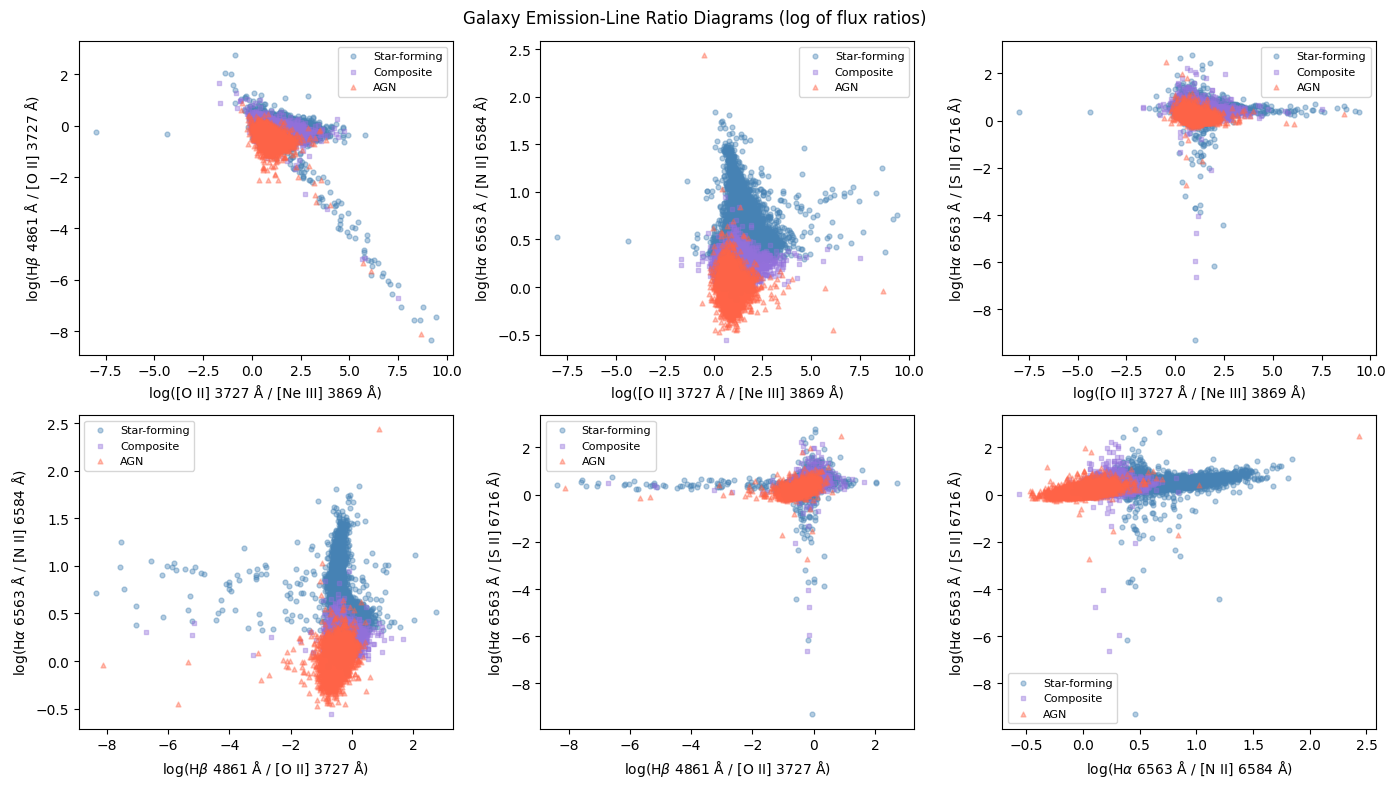

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (x_name, y_name) in zip(axes, combinations(ratio_values.keys(), 2)):
    x = ratio_values[x_name]
    y = ratio_values[y_name]
    for gtype in ["S", "C", "A"]:
        style = type_style[gtype]
        mask = labels == gtype
        ax.scatter(x[mask], y[mask], alpha=0.4, s=12, **style)
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.legend(fontsize=8)

plt.suptitle("Galaxy Emission-Line Ratio Diagrams (log of flux ratios)")
plt.tight_layout()
plt.show()